### Determine the number of transcripts needed for stable pseudobulk analysis

Each donor has a certain number of cells for each cell type, but it is unclear how many counts are required to get a reliable 'donor profile' for that cell type. Here we will down-sample counts for several different donors, to identify an optimal number of counts for reliable approximation of a donor's cell-type specific profile.

In [1]:
import scanpy as sc 
import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
plots_dir = "pseudobulk_analysis_plots/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
def downsample_total_counts(counts, target_depth, random_state=42):

    ''' 
    Downsample counts according to the multinomial distribution 
    '''
    
    rng = np.random.default_rng(random_state)
    counts = np.array(counts).flatten()  # ensure 1D dimension
    total = counts.sum() # sum over the counts
    if total <= target_depth: 
        return counts.copy()
    probs = counts / total
    sampled = rng.multinomial(target_depth, probs)
    return sampled

In [4]:
def obtain_pseudobulked_counts_for_donor(adata, donor_id):
    '''Obtain pseudobulked counts for a donor'''
    
    donor_only_adata = adata[adata.obs.donor_id == donor_id].copy()
    counts_full = donor_only_adata.layers['counts'].sum(axis = 0)
    counts_full_2d = counts_full.reshape(1, -1)

    return(counts_full_2d)

In [5]:
def downsampling_function(counts_full_2d):

    ''' Iterate through a list of different number of transcripts (UMIs) to downsample the full pseudobulked 
    counts to''' 
    
    targets = [100, 500, 1000, 5000, 10000, 25000, 50000, 100000, 200000, 300000, 500000, 1000000]
    
    results = []

    # ensure counts_full_2d is a 1D array of pseudobulk counts
    gene_means_full_1d = np.array(counts_full_2d).flatten()

    for target in targets:
        ds = downsample_total_counts(counts_full_2d, target, random_state=42)
        
        # ensure ds is 1D
        ds_1d = np.array(ds).flatten()
        
        # only keep genes with non-zero expression in either the full or subsampled
        valid = (gene_means_full_1d > 0) | (ds_1d > 0)

        # calculate spearman correlation
        spear, _ = spearmanr(gene_means_full_1d[valid], ds_1d[valid])
        
        results.append({
            "target": target,
            "spearman": spear
        })

    df = pd.DataFrame(results)
    return df

In [6]:
def filter_features_by_cell_fraction(adata, min_fraction):
    '''Keep only the features present in at least min_fraction of cells'''
    # compute fraction of cells with non-zero counts per feature
    gene_mask = np.array((adata.X > 0).sum(axis=0)).flatten() / adata.n_obs >= min_fraction
    
    # subsetting
    adata_filtered = adata[:, gene_mask].copy()
    print(f"Kept {adata_filtered.n_vars} features out of {adata.n_vars} ({min_fraction*100}% minimum cells)")
    return adata_filtered

In [7]:
%%time
adata = sc.read_h5ad("../07_final_ATAC.h5ad")

CPU times: user 3.96 s, sys: 35.5 s, total: 39.5 s
Wall time: 45 s


In [8]:
adata.shape

(690044, 654221)

In [9]:
Cardiomyocyte_adata = adata[adata.obs.final_cell_type == "Cardiomyocyte"].copy()

In [10]:
Cardiomyocyte_adata

AnnData object with n_obs × n_vars = 291398 × 654221
    obs: 'ATAC_barcode', 'sample_id', 'leiden', 'donor_id', 'study', 'age_status', 'age', 'sex', 'region', 'disease_binary', 'technology', 'fragment_file', 'full_path', 'file', 'nfrag', 'tsse', 'cell_type', 'tech_plus_study', 'age_group', 'decade', 'final_cell_type', 'cell_or_nuclei', 'disease'
    var: 'count', 'selected'
    uns: 'age_status_colors', 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'spectral_eigenvalue', 'study_colors'
    obsm: 'X_spectral', 'X_spectral_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

In [11]:
filt_CM_adata = filter_features_by_cell_fraction(Cardiomyocyte_adata, min_fraction=0.01)
filt_CM_adata.layers['counts'] = filt_CM_adata.X

Kept 130862 features out of 654221 (1.0% minimum cells)


In [12]:
filt_CM_adata.shape

(291398, 130862)

In [13]:
donor_counts = Counter(filt_CM_adata.obs['donor_id'])
top5 = donor_counts.most_common(5)
print(top5)

top5_ids = [donor for donor, count in top5]
print(top5_ids)

[('Penn:Penn_F2', 14077), ('Kanemaru 2023:AH1-Nuclei_Multiome-v1', 9219), ('Penn:Penn_F1', 8730), ('Penn:Penn_F5', 7814), ('ENCODE v4 (Snyder):ENCFF849ALE', 7406)]
['Penn:Penn_F2', 'Kanemaru 2023:AH1-Nuclei_Multiome-v1', 'Penn:Penn_F1', 'Penn:Penn_F5', 'ENCODE v4 (Snyder):ENCFF849ALE']


In [14]:
CM_res_list = list()

for donor in top5_ids: 
    full_donor_counts = obtain_pseudobulked_counts_for_donor(filt_CM_adata, donor_id = donor)
    correlation_df =  downsampling_function(full_donor_counts)
    correlation_df['donor_id'] = donor
    CM_res_list.append(correlation_df)

CM_res_df = pd.concat(CM_res_list)

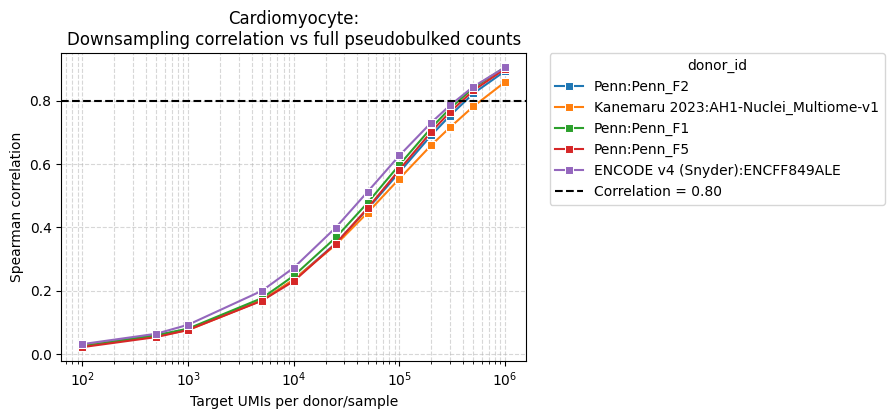

In [31]:
fig, ax = plt.subplots(figsize=(6,4))  # fixed size for the main plot

sns.lineplot(
    data=CM_res_df,
    x="target",
    y="spearman",
    hue="donor_id",
    marker="s",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Target UMIs per donor/sample")
ax.set_ylabel("Spearman correlation")
ax.set_title("Cardiomyocyte:\nDownsampling correlation vs full pseudobulked counts")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# add horizontal line at 0.80
ax.axhline(0.80, color='black', linestyle='--', label='Correlation = 0.80')

# put legend outside without changing main plot size
ax.legend(
    title="donor_id",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

# save full figure with legend included
fig.savefig(plots_dir + "CM_downsampling_plot.pdf", bbox_inches="tight")
plt.show()

### Also test this for another common cell type (e.g., Myeloid)

In [16]:
Myeloid_adata = adata[adata.obs.final_cell_type == "Myeloid"].copy()

In [17]:
filt_Myeloid_adata = filter_features_by_cell_fraction(Myeloid_adata, min_fraction=0.01)
filt_Myeloid_adata.layers['counts'] = filt_Myeloid_adata.X

Kept 57241 features out of 654221 (1.0% minimum cells)


In [18]:
donor_counts = Counter(filt_Myeloid_adata.obs['donor_id'])
top5 = donor_counts.most_common(5)
print(top5)

top5_ids = [donor for donor, count in top5]
print(top5_ids)

[('ENCODE v4 (Snyder):ENCSR175TRJ', 3027), ('ENCODE v4 (Snyder):ENCSR762LML', 2051), ('ENCODE v4 (Snyder):ENCSR157FDD', 1796), ('Kanemaru 2023:AH1-Nuclei_Multiome-v1', 1752), ('ENCODE v4 (Snyder):ENCSR084XKX', 1434)]
['ENCODE v4 (Snyder):ENCSR175TRJ', 'ENCODE v4 (Snyder):ENCSR762LML', 'ENCODE v4 (Snyder):ENCSR157FDD', 'Kanemaru 2023:AH1-Nuclei_Multiome-v1', 'ENCODE v4 (Snyder):ENCSR084XKX']


In [19]:
Myeloid_res_list = list()

for donor in top5_ids: 
    full_donor_counts = obtain_pseudobulked_counts_for_donor(filt_Myeloid_adata, donor_id = donor)
    correlation_df =  downsampling_function(full_donor_counts)
    correlation_df['donor_id'] = donor
    Myeloid_res_list.append(correlation_df)

Myeloid_res_df = pd.concat(Myeloid_res_list)

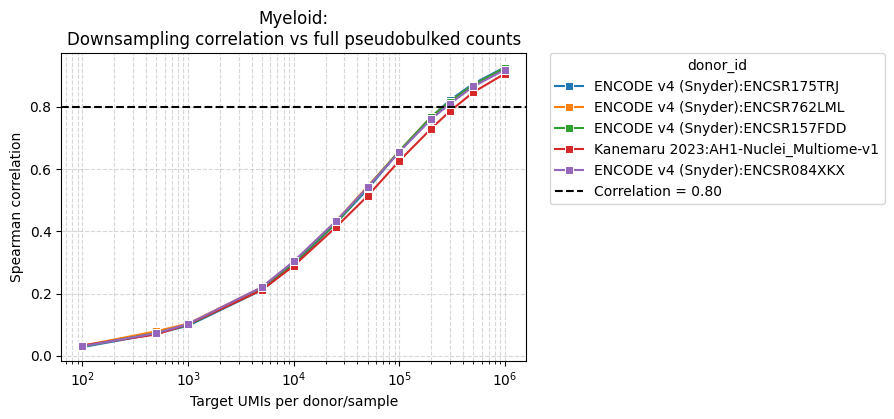

In [32]:
fig, ax = plt.subplots(figsize=(6,4))  # fixed size for the main plot

sns.lineplot(
    data=Myeloid_res_df,
    x="target",
    y="spearman",
    hue="donor_id",
    marker="s",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Target UMIs per donor/sample")
ax.set_ylabel("Spearman correlation")
ax.set_title("Myeloid:\nDownsampling correlation vs full pseudobulked counts")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# add horizontal line at 0.80
ax.axhline(0.80, color='black', linestyle='--', label='Correlation = 0.80')

# put legend outside without changing main plot size
ax.legend(
    title="donor_id",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

# save full figure with legend included
fig.savefig(plots_dir + "Myeloid_downsampling_plot.pdf", bbox_inches="tight")
plt.show()

### Now, perform for a rarer cell type (Lymphoid)

In [21]:
Lymphoid_adata = adata[adata.obs.final_cell_type == "Lymphoid"].copy()

In [22]:
filt_Lymphoid_adata = filter_features_by_cell_fraction(Lymphoid_adata, min_fraction=0.01)
filt_Lymphoid_adata.layers['counts'] = filt_Lymphoid_adata.X

Kept 31502 features out of 654221 (1.0% minimum cells)


In [23]:
donor_counts = Counter(filt_Lymphoid_adata.obs['donor_id'])
top5 = donor_counts.most_common(5)
print(top5)

top5_ids = [donor for donor, count in top5]
print(top5_ids)

[('ENCODE v4 (Snyder):ENCSR175TRJ', 1678), ('ENCODE v4 (Snyder):ENCSR777RUZ', 1403), ('ENCODE v4 (Snyder):ENCSR762LML', 991), ('Penn:Penn_F2', 916), ('ENCODE v4 (Snyder):ENCSR455MGH', 779)]
['ENCODE v4 (Snyder):ENCSR175TRJ', 'ENCODE v4 (Snyder):ENCSR777RUZ', 'ENCODE v4 (Snyder):ENCSR762LML', 'Penn:Penn_F2', 'ENCODE v4 (Snyder):ENCSR455MGH']


In [24]:
Lymphoid_res_list = list()

for donor in top5_ids: 
    full_donor_counts = obtain_pseudobulked_counts_for_donor(filt_Lymphoid_adata, donor_id = donor)
    correlation_df =  downsampling_function(full_donor_counts)
    correlation_df['donor_id'] = donor
    Lymphoid_res_list.append(correlation_df)

Lymphoid_res_df = pd.concat(Lymphoid_res_list)

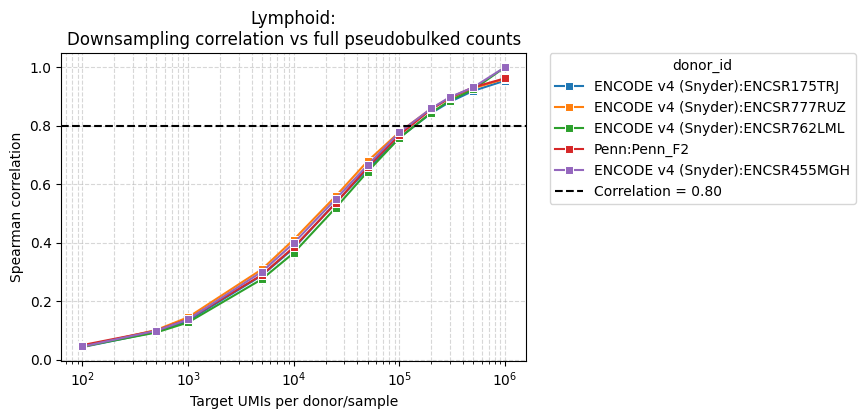

In [33]:
fig, ax = plt.subplots(figsize=(6,4))  # fixed size for the main plot

sns.lineplot(
    data=Lymphoid_res_df,
    x="target",
    y="spearman",
    hue="donor_id",
    marker="s",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Target UMIs per donor/sample")
ax.set_ylabel("Spearman correlation")
ax.set_title("Lymphoid:\nDownsampling correlation vs full pseudobulked counts")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# add horizontal line at 0.80
ax.axhline(0.80, color='black', linestyle='--', label='Correlation = 0.80')

# put legend outside without changing main plot size
ax.legend(
    title="donor_id",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

# save full figure with legend included
fig.savefig(plots_dir + "Lymphoid_downsampling_plot.pdf", bbox_inches="tight")
plt.show()

### vSMC

In [26]:
vSMC_adata = adata[adata.obs.final_cell_type == "vSMC"].copy()

In [27]:
filt_vSMC_adata = filter_features_by_cell_fraction(vSMC_adata, min_fraction=0.01)
filt_vSMC_adata.layers['counts'] = filt_vSMC_adata.X

Kept 45632 features out of 654221 (1.0% minimum cells)


In [28]:
donor_counts = Counter(filt_vSMC_adata.obs['donor_id'])
top5 = donor_counts.most_common(5)
print(top5)

top5_ids = [donor for donor, count in top5]
print(top5_ids)

[('ENCODE v4 (Snyder):ENCSR919ENI', 453), ('ENCODE v4 (Snyder):ENCSR851JBE', 198), ('ENCODE v4 (Snyder):ENCSR405YKM', 195), ('ENCODE v4 (Snyder):ENCSR002SMQ', 187), ('ENCODE v4 (Snyder):ENCSR084XKX', 175)]
['ENCODE v4 (Snyder):ENCSR919ENI', 'ENCODE v4 (Snyder):ENCSR851JBE', 'ENCODE v4 (Snyder):ENCSR405YKM', 'ENCODE v4 (Snyder):ENCSR002SMQ', 'ENCODE v4 (Snyder):ENCSR084XKX']


In [29]:
vSMC_res_list = list()

for donor in top5_ids: 
    full_donor_counts = obtain_pseudobulked_counts_for_donor(filt_vSMC_adata, donor_id = donor)
    correlation_df =  downsampling_function(full_donor_counts)
    correlation_df['donor_id'] = donor
    vSMC_res_list.append(correlation_df)

vSMC_res_df = pd.concat(vSMC_res_list)

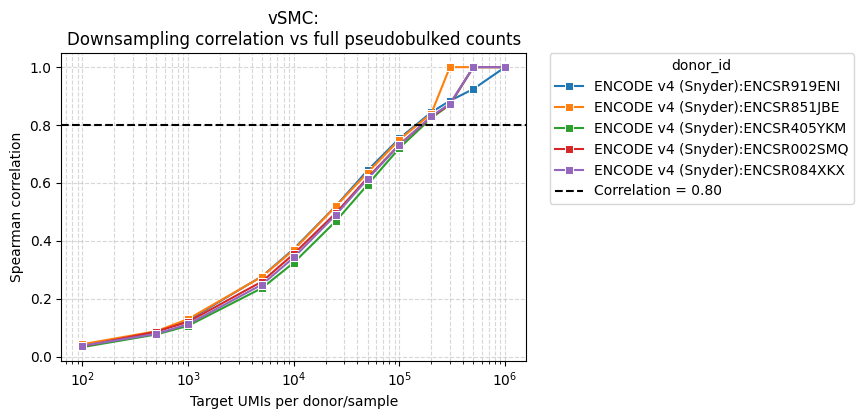

In [34]:
fig, ax = plt.subplots(figsize=(6,4))  # fixed size for the main plot

sns.lineplot(
    data=vSMC_res_df,
    x="target",
    y="spearman",
    hue="donor_id",
    marker="s",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Target UMIs per donor/sample")
ax.set_ylabel("Spearman correlation")
ax.set_title("vSMC:\nDownsampling correlation vs full pseudobulked counts")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# add horizontal line at 0.80
ax.axhline(0.80, color='black', linestyle='--', label='Correlation = 0.80')

# put legend outside without changing main plot size
ax.legend(
    title="donor_id",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

# save full figure with legend included
fig.savefig(plots_dir + "vSMC_downsampling_plot.pdf", bbox_inches="tight")
plt.show()